In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('14.csv')

# Print the first 5 rows
print("--- First 5 rows ---")
print(df.head())
print("\n")

# List all the column names
print("--- Column Names ---")
print(df.columns.tolist())
print("\n")

# Display the total number of rows and columns
rows, columns = df.shape
print("--- Dataset Shape ---")
print(f"Total rows: {rows}")
print(f"Total columns: {columns}")

--- First 5 rows ---
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                       

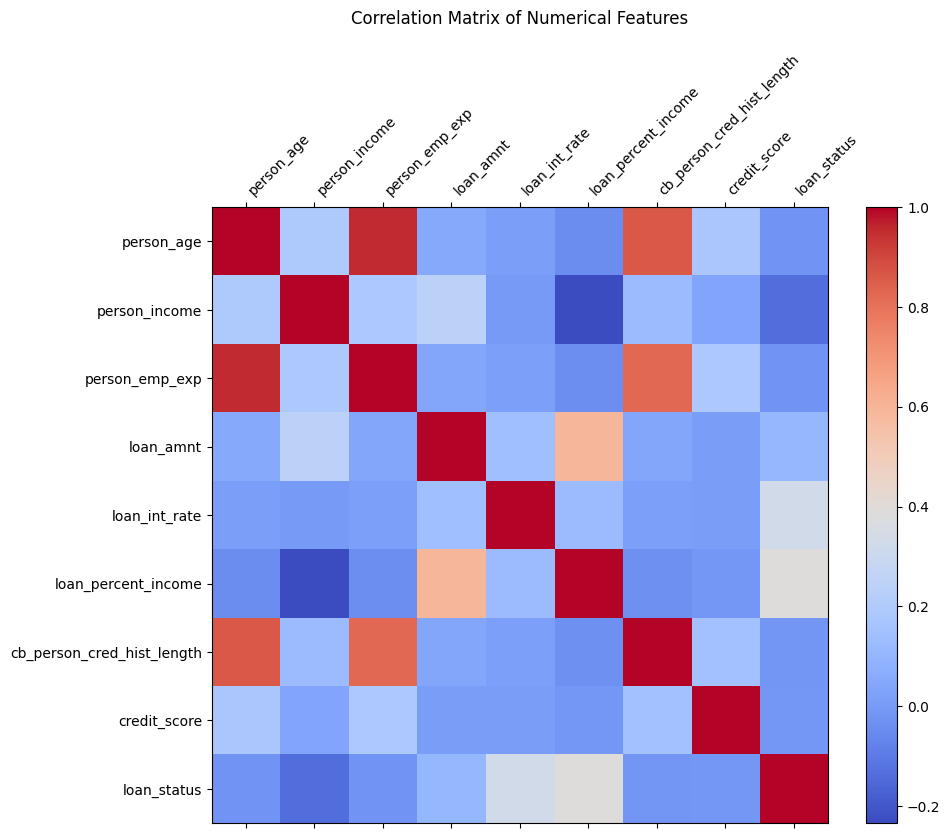


Preprocessing is complete! Target separated, categories encoded, and features scaled.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv('14.csv')

# 1. Isolate numerical features and calculate correlation
numerical_features = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_features.corr()

# 2. Display correlation matrix using a stable matplotlib method
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)

# Add labels to make the chart readable
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)
plt.title("Correlation Matrix of Numerical Features", pad=20)
plt.show()

# 3. Separate the target variable from the features
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 4. Encode categorical text columns into numbers
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# 5. Apply StandardScaler to scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nPreprocessing is complete! Target separated, categories encoded, and features scaled.")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

# 1. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Supervised Models
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Model 3: Neural Network (Multi-Layer Perceptron)
nn_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300, random_state=42)
nn_model.fit(X_train, y_train)

# 3. Unsupervised Model (K-Means Clustering)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train)

print("Step 3 Complete: All models (Logistic Regression, Decision Tree, Neural Network, and K-Means) trained successfully!")

Step 3 Complete: All models (Logistic Regression, Decision Tree, Neural Network, and K-Means) trained successfully!


=== Model Comparison Metrics ===
               Model  Accuracy  Precision  Recall  F1 Score  AUC Score
 Logistic Regression    0.8901     0.7663  0.7308    0.7482     0.9483
       Decision Tree    0.8984     0.7740  0.7701    0.7721     0.8527
Neural Network (MLP)    0.9153     0.8728  0.7269    0.7932     0.9660


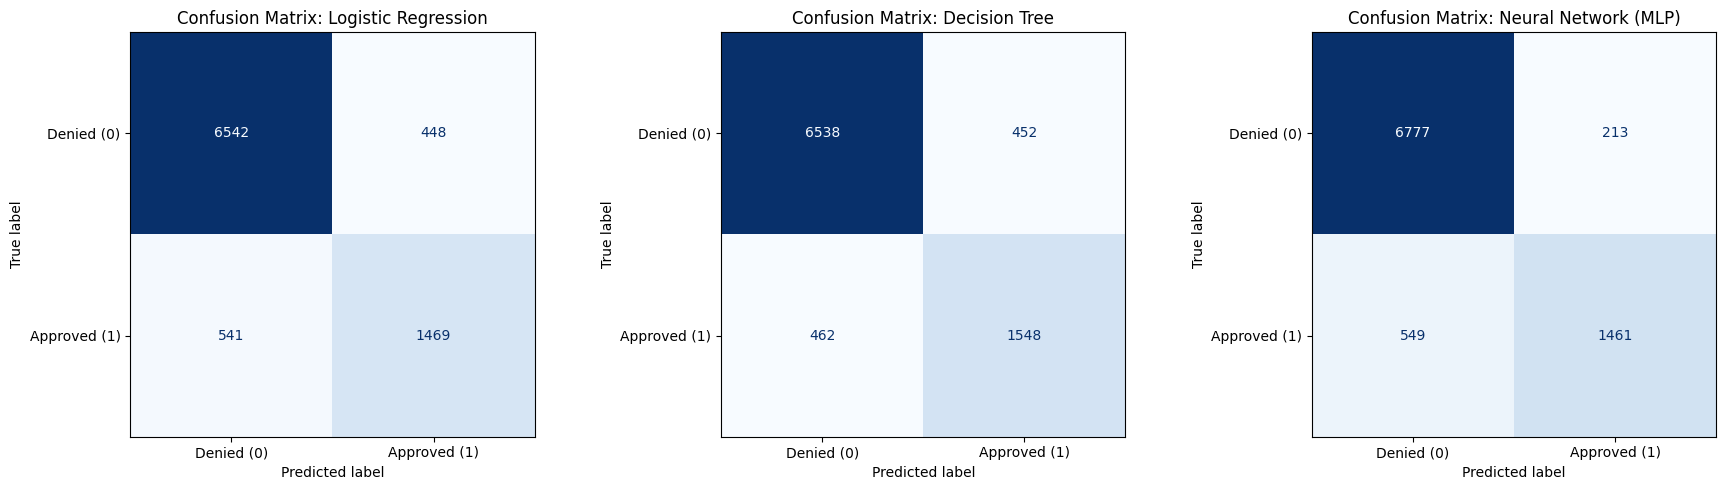

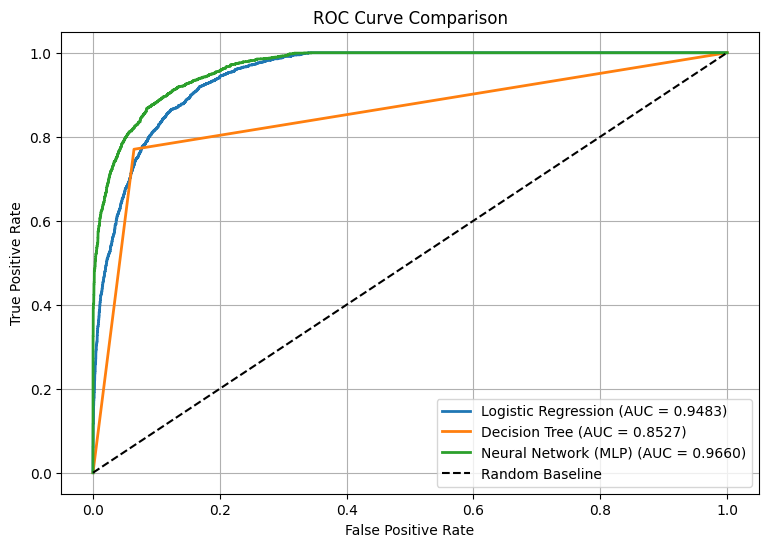

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Dictionary of trained supervised models
trained_models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt_model,
    "Neural Network (MLP)": nn_model
}

# 1. Performance Metrics Table
results_data = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results_data.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "AUC Score": round(auc, 4)
    })

results_df = pd.DataFrame(results_data)
print("=== Model Comparison Metrics ===")
print(results_df.to_string(index=False))

# 2. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied (0)', 'Approved (1)'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

# 3. Combined ROC Curves
plt.figure(figsize=(9, 6))
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()